In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import math
import seaborn as sns
import gc
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.decomposition import PCA
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
train_transaction = pd.read_csv('./dataset/train_transaction.csv')
train_identity = pd.read_csv('./dataset/train_identity.csv')
# test_transaction = pd.read_csv('./dataset/test_transaction.csv')
# test_identity = pd.read_csv('./dataset/test_identity.csv')

In [3]:
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
df.head(1)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['DeviceInfo'].value_counts()

DeviceInfo
Windows        47722
iOS Device     19782
MacOS          12573
Trident/7.0     7440
rv:11.0         1901
               ...  
LGMS345            1
verykool           1
XT1072             1
LG-H931            1
0PJA2              1
Name: count, Length: 1786, dtype: int64

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
 

In [3]:
train_transaction.head(1).T

,0
TransactionID,2987000
isFraud,0
TransactionDT,86400
TransactionAmt,68.5
ProductCD,W
...,...
V335,NaN
V336,NaN
V337,NaN
V338,NaN


# Tes fraud per user

In [4]:
categorical_cols = train_identity.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    train_identity[col] = train_identity[col].fillna('null')

for col in train_identity.select_dtypes(include=np.number).columns:
    train_identity[col] = train_identity[col].fillna(-999)

encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    dff = pd.concat([train_identity[col]], axis=0).sort_values().unique()
    encoder.fit(dff)
    # encoder.fit(pd.concat([train[col], test[col]], axis=0).unique())

    train_identity[col] = encoder.transform(train_identity[col])

    encoders[col] = encoder

# Perform PCA
pca = PCA(n_components=1)
pca_result = pca.fit_transform(train_identity.iloc[:, 1:])

# Add the PCA result as a new column to the original DataFrame
train_identity['PCA_1'] = None
train_identity.loc[train_identity.index, 'PCA_1'] = pca_result[:, 0]

# train_identity['PCA_1'].head()
pca1 = train_identity['PCA_1']
train_identity = pd.read_csv('./dataset/train_identity.csv')
train_identity['PCA_1'] = pca1
train_identity

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,PCA_1
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,-99835.254182
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device,-71676.903723
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,F,F,T,T,desktop,Windows,21009.222251
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,F,F,T,T,desktop,NaN,51211.720515
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS,-163163.225592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144228,3577521,-15.0,145955.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97,-24666.218164
144229,3577526,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,...,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F,1437.45955
144230,3577529,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,...,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152,461760.372485
144231,3577531,-5.0,55528.0,0.0,0.0,0.0,-7.0,NaN,NaN,0.0,...,24.0,2560x1600,match_status:2,T,F,T,F,desktop,MacOS,-115095.038975


In [5]:
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
df_test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')
print(f"train shape: {df.shape}")
print(f"test shape: {df_test.shape}")

train shape: (590540, 435)
test shape: (506691, 433)


In [6]:
trans_counts = df.groupby('PCA_1').size().sort_values(ascending=False)
trans_counts = trans_counts.reset_index(name='counts')

fraud_counts = df[df['isFraud'] == 1].groupby('PCA_1').size().sort_values(ascending=False)
fraud_counts = fraud_counts.reset_index(name='fraud_counts')

merged_counts = pd.merge(trans_counts, fraud_counts, on='PCA_1', how='inner')
merged_counts = merged_counts.sort_values(by='fraud_counts', ascending=False)
merged_counts.head(10)

,PCA_1,counts,fraud_counts
2,-171620.520413,481,38
1,-171620.518379,673,28
0,-171620.520413,1984,20
3,-171620.510584,38,8
6,-170098.147534,3,3
15,-169716.148186,2,2
25,-170380.147053,2,2
24,-170361.220901,2,2
23,-85278.541193,2,2
21,-168870.770580,2,2


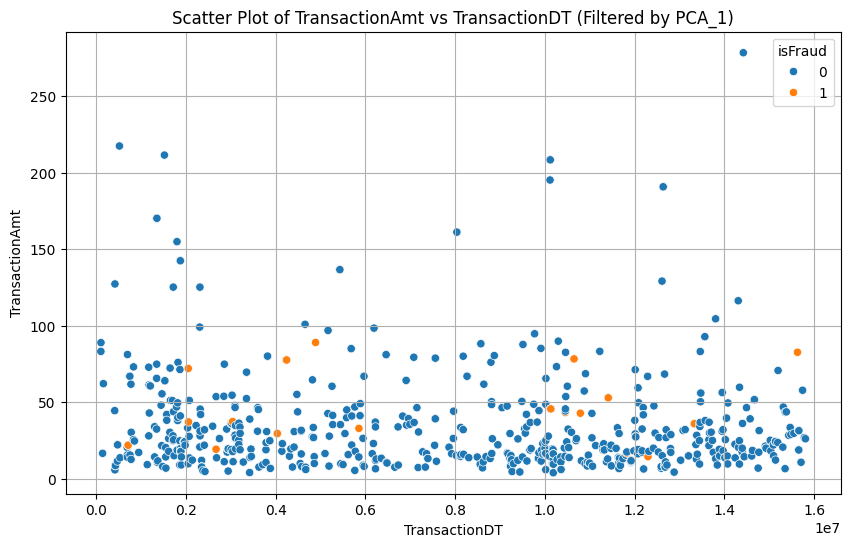

In [7]:
# Filter the data for the specific PCA_1 value
filtered_data = df[df['PCA_1'] == merged_counts.head(10)['PCA_1'].values[1]]

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=filtered_data, x='TransactionDT', y='TransactionAmt', hue='isFraud')
plt.title('Scatter Plot of TransactionAmt vs TransactionDT (Filtered by PCA_1)')
plt.xlabel('TransactionDT')
plt.ylabel('TransactionAmt')
plt.grid(True)
plt.legend(title='isFraud')
plt.show()

# Cek duplikat

In [4]:
df_duplicates = df[df.duplicated(subset='TransactionID', keep=False)]
print(f"Duplicated rows in df: {df_duplicates.shape[0]}")

df_test_duplicates = df_test[df_test.duplicated(subset='TransactionID', keep=False)]
print(f"Duplicated rows in df_test: {df_test_duplicates.shape[0]}")

Duplicated rows in df: 0
Duplicated rows in df_test: 0


## Yang bener

In [9]:
duplicates = df.drop(columns=['TransactionID']).duplicated(keep=False)
df_duplicates = df[duplicates].drop(columns=['TransactionID'])
print(f"Number of duplicate rows (excluding TransactionID): {df_duplicates.shape[0]}")

Number of duplicate rows (excluding TransactionID): 6


Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
 

Ternyata ada 6 data terduplikasi jika ngeceknya tanpa ID

In [6]:
df_duplicates

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
295456,0,7310775,47.95,W,7919,194.0,150.0,mastercard,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
295457,0,7310775,47.95,W,7919,194.0,150.0,mastercard,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
453414,0,11576951,512.95,W,1359,314.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
453415,0,11576951,512.95,W,1359,314.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
570433,0,15129302,44.00,W,2744,490.0,150.0,visa,195.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
570434,0,15129302,44.00,W,2744,490.0,150.0,visa,195.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Get the indices of the 2nd, 4th, and 6th rows in df_duplicates
duplicated_index = df_duplicates.index[[1, 3, 5]]
print(duplicated_index.tolist())

# Drop the rows with the specified indices
df = df.drop(duplicated_index).reset_index(drop=True)

[295457, 453415, 570434]


In [ ]:

print(f"Updated df shape after removing specified indices: {df.shape}")

In [7]:
df['id_35'].unique()

array([nan, 'T', 'F'], dtype=object)

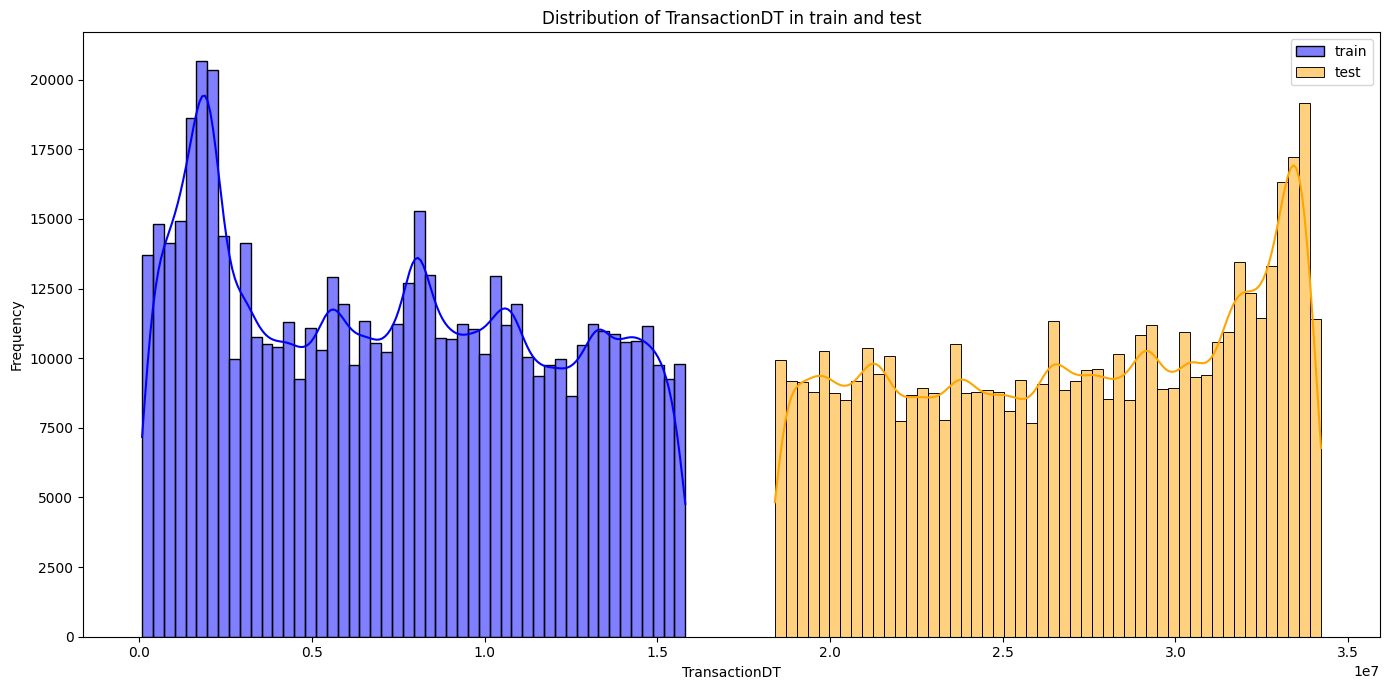

In [13]:
plt.figure(figsize=(14, 7))

sns.histplot(df['TransactionDT'], bins=50, kde=True, color='blue', label='train')
sns.histplot(df_test['TransactionDT'], bins=50, kde=True, color='orange', label='test')

plt.title('Distribution of TransactionDT in train and test')
plt.xlabel('TransactionDT')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

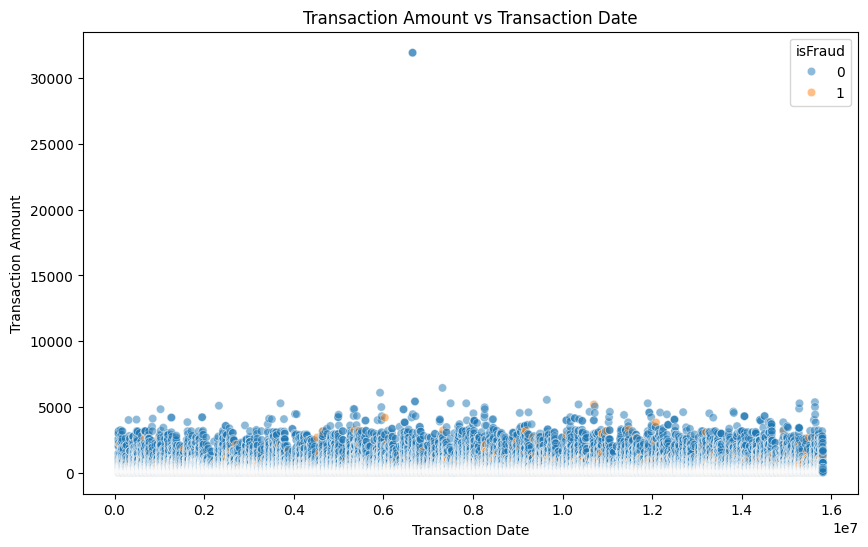

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='TransactionDT', y='TransactionAmt', hue='isFraud', alpha=0.5)
plt.title('Transaction Amount vs Transaction Date')
plt.xlabel('Transaction Date')
plt.ylabel('Transaction Amount')
plt.show()

In [ ]:
high_value_transactions = df[df['TransactionAmt'] > 10000]
high_value_transactions

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
274336,3261336,0,6652360,31937.391,W,16075,514.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
274339,3261339,0,6652391,31937.391,W,16075,514.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
 

In [10]:
df = df.drop(high_value_transactions.index).reset_index(drop=True)
print(f"Updated train shape: {df.shape}")

Updated train shape: (590538, 434)


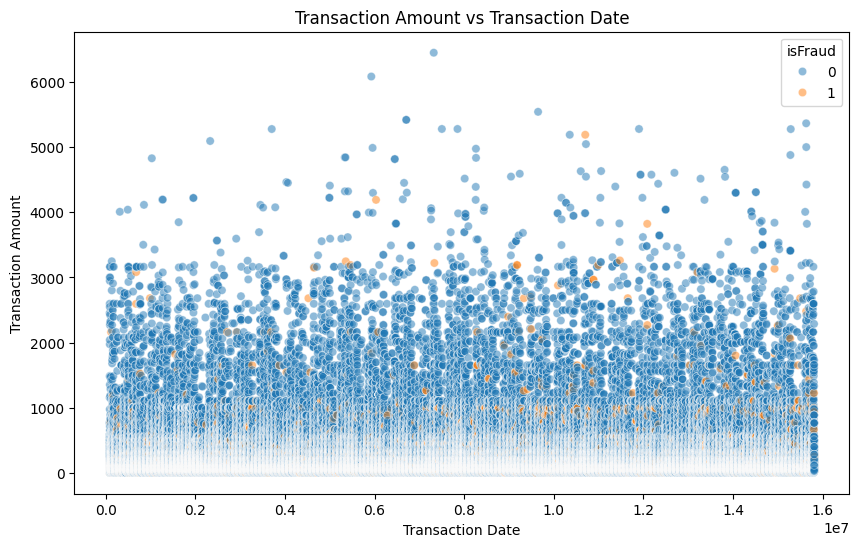

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='TransactionDT', y='TransactionAmt', hue='isFraud', alpha=0.5)
plt.title('Transaction Amount vs Transaction Date')
plt.xlabel('Transaction Date')
plt.ylabel('Transaction Amount')
plt.show()

In [7]:
df_test.columns = df_test.columns.str.replace('^id-', 'id_', regex=True) 

In [5]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
       'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33',
       'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType',
       'DeviceInfo'],
      dtype='object')


In [9]:
df['DeviceInfo'].value_counts()

DeviceInfo
Windows        47722
iOS Device     19782
MacOS          12573
Trident/7.0     7440
rv:11.0         1901
               ...  
LGMS345            1
verykool           1
XT1072             1
LG-H931            1
0PJA2              1
Name: count, Length: 1786, dtype: int64

In [10]:
df = df.drop(columns=['PCA_1'])

In [11]:
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,null,NaN,null,null,null,null,null,null,null,null
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,null,NaN,null,null,null,null,null,null,null,null
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,null,NaN,null,null,null,null,null,null,null,null
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,null,NaN,null,null,null,null,null,null,null,null
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,null,NaN,null,null,null,null,null,null,null,null
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,null,NaN,null,null,null,null,null,null,null,null
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,null,NaN,null,null,null,null,null,null,null,null
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,null,NaN,null,null,null,null,null,null,null,null


In [12]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df[col] = df[col].fillna('null')
    df_test[col] = df_test[col].fillna('null')

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(-999)

for col in df_test.select_dtypes(include=np.number).columns:
    df_test[col] = df_test[col].fillna(-999)

In [13]:
encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    dff = pd.concat([df[col],df_test[col]], axis=0).sort_values().unique()
    encoder.fit(dff)
    # encoder.fit(pd.concat([train[col], test[col]], axis=0).unique())

    df[col] = encoder.transform(df[col])
    df_test[col] = encoder.transform(df_test[col])

    if df[col].max() > 32000 or df_test[col].max() > 32000:
        df[col] = df[col].astype('int32')
        df_test[col] = df_test[col].astype('int32')
    else:
        df[col] = df[col].astype('int16')
        df_test[col] = df_test[col].astype('int16')

    encoders[col] = encoder

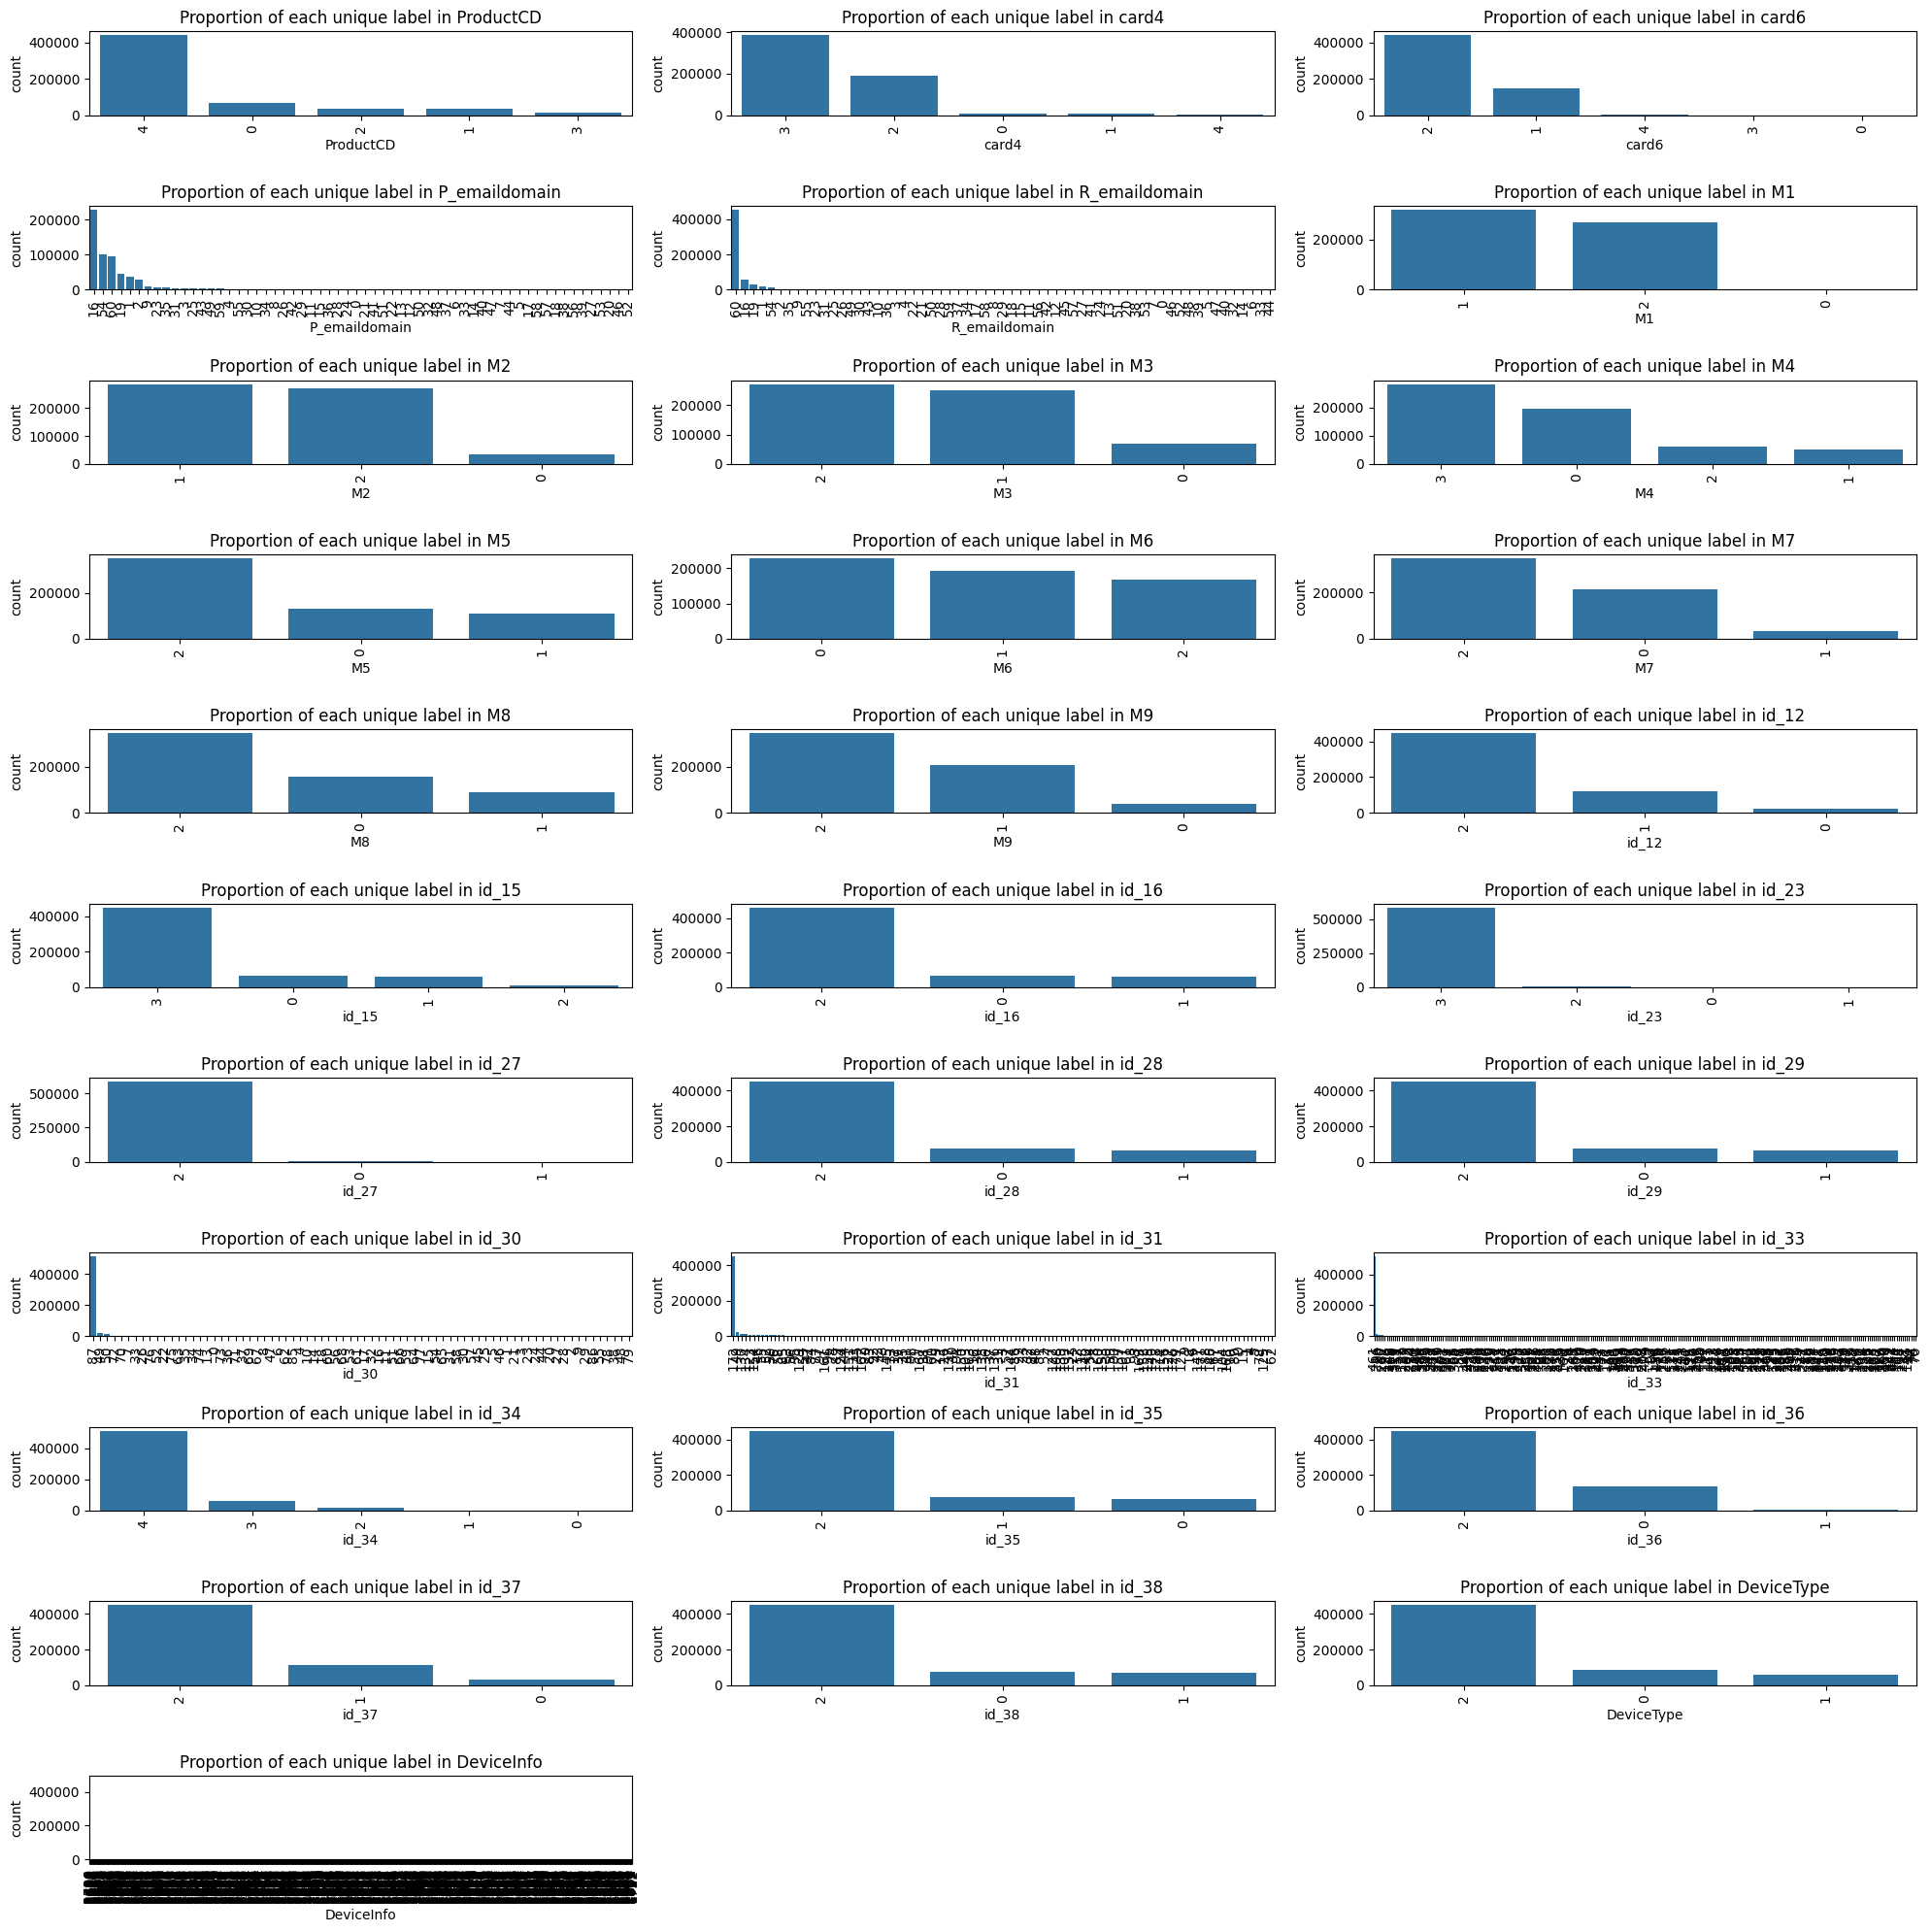

In [14]:
plt.figure(figsize=(20, 20))

for i, col in enumerate(categorical_cols):
    plt.subplot(math.ceil(len(categorical_cols) / 3), 3, i + 1)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Proportion of each unique label in {col}')
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [11]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Get the correlation values for 'isFraud'
fraud_corr = corr_matrix['isFraud'].abs().sort_values(ascending=False)

# Select the top 5 and bottom 5 correlations (excluding 'isFraud' itself)
top_5_corr = fraud_corr[1:6]
bottom_5_corr = fraud_corr[-5:]

print("Top 5 absolute correlations with isFraud:")
print(top_5_corr)

print("\nBottom 5 absolute correlations with isFraud:")
print(bottom_5_corr)

Top 5 absolute correlations with isFraud:
id_35        0.164236
addr2        0.159654
D7           0.157434
ProductCD    0.156556
addr1        0.154174
Name: isFraud, dtype: float64

Bottom 5 absolute correlations with isFraud:
V300    0.000160
V301    0.000098
V296    0.000025
V319    0.000016
V288    0.000010
Name: isFraud, dtype: float64


In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Get the correlation values for 'isFraud'
fraud_corr = corr_matrix['isFraud']

# Select the best 5 and worst 5 correlations (excluding 'isFraud' itself)
best_5_corr = fraud_corr.drop('isFraud').nlargest(5)
worst_5_corr = fraud_corr.drop('isFraud').nsmallest(5)

print("Best 5 correlations with isFraud:")
print(best_5_corr)

print("\nWorst 5 correlations with isFraud:")
print(worst_5_corr)

In [17]:
drop_column = ['id_07','id_21', 'id_22', 'id_23','id_24', 'id_25', 'id_26', 'id_27', 'TransactionID']   # drop columns
df.drop(drop_column, axis=1, inplace=True)
df_test.drop(drop_column, axis=1, inplace=True)

In [18]:
print("setelah preprocessing")
print(f"train shape: {df.shape}")
print(f"test shape: {df_test.shape}")

setelah preprocessing
train shape: (590538, 425)
test shape: (506691, 424)


In [19]:
x = df.drop('isFraud', axis=1)
y = df['isFraud']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

test_scaled = scaler.fit_transform(df_test)
test_scaled = pd.DataFrame(test_scaled, columns=df_test.columns)

x_train, x_val, y_train, y_val = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [20]:
model = xgb.XGBClassifier(random_state=42)  # You can customize hyperparameters here
model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob = model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred = model.predict(x_val)

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_val, y_pred_prob)
print(f"AUC-ROC score: {auc_roc}")
print(classification_report(y_val, y_pred))

AUC-ROC score: 0.9436054261667581
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113861
           1       0.93      0.50      0.65      4247

    accuracy                           0.98    118108
   macro avg       0.95      0.75      0.82    118108
weighted avg       0.98      0.98      0.98    118108



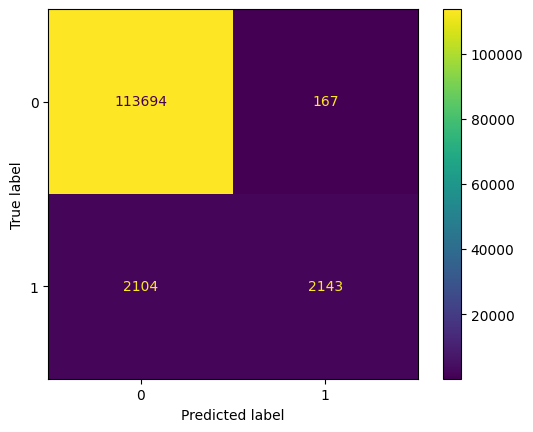

In [21]:
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [13]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Get the correlation values for 'isFraud'
fraud_corr = corr_matrix['isFraud']

# Select the best 5 and worst 5 correlations (excluding 'isFraud' itself)
best_5_corr = fraud_corr.drop('isFraud').nlargest(5)
worst_5_corr = fraud_corr.drop('isFraud').nsmallest(5)

print("Best 5 correlations with isFraud:")
print(best_5_corr)

print("\nWorst 5 correlations with isFraud:")
print(worst_5_corr)

Best 5 correlations with isFraud:
D7       0.157434
D12      0.154050
D14      0.149178
id_10    0.144142
id_09    0.144141
Name: isFraud, dtype: float64

Worst 5 correlations with isFraud:
id_35       -0.164236
addr2       -0.159654
ProductCD   -0.156556
addr1       -0.154174
id_29       -0.151940
Name: isFraud, dtype: float64


Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
 

In [ ]:
# Calculate the correlation matrix
# corr_matrix = df.corr()

# Get the correlation values for 'isFraud'
fraud_corr = corr_matrix['isFraud'].abs().sort_values(ascending=False)

# Select the top 10 correlations (excluding 'isFraud' itself)
top_10_corr = fraud_corr[1:11]

# Create a heatmap for the top 10 correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_10_corr.index].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Top 10 Correlations with isFraud')
plt.show()

ValueError: could not convert string to float: 'null'